Project root: c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit

 COMPUTE MODE
  CUDA Available: False
  Device: CPU (forced)


 EXPERIMENT SMALL - Quick Benchmarking
  Row limit:       5000
  CV splits:       1
  Max epochs:      15
  HPO:             False
  Device:          CPU
  Excluded:        None

PD Datasets (1): ['0009.german']
LGD Datasets (1): ['0004.base_model']

PD Methods (17): ['catboost', 'knn', 'lightgbm', 'LogReg', 'NaiveBayes', 'RandomForest', 'svm', 'xgboost', 'NCM', 'dummy', 'mlp', 'tabnet', 'tabpfn', 'tabpfn_v2', 'resnet', 'ftt', 'tabr']
LGD Methods (13): ['catboost', 'knn', 'lightgbm', 'LinearRegression', 'RandomForest', 'xgboost', 'svm', 'mlp', 'tabnet', 'tabpfn_v2', 'resnet', 'ftt', 'tabr']


 Running PD Experiments
  Datasets: 1
  Methods:  17
  Total:    17 experiments
  Metric:   AUC



PD: 0009.german          + tabpfn         :  71%|███████   | 12/17 [00:30<00:04,  1.18it/s]

  ERROR: tabnet on 0009.german - Torch not compiled with CUDA enabled


PD: 0009.german          + tabr           : 100%|██████████| 17/17 [01:10<00:00,  4.12s/it]



 Running LGD Experiments
  Datasets: 1
  Methods:  13
  Total:    13 experiments
  Metric:   R2



LGD: 0004.base_model      + tabpfn_v2      :  69%|██████▉   | 9/13 [01:08<00:23,  5.86s/it]

  ERROR: tabnet on 0004.base_model - Torch not compiled with CUDA enabled


LGD: 0004.base_model      + tabr           : 100%|██████████| 13/13 [03:06<00:00, 14.34s/it]



✓ All experiments completed!

 PD RESULTS (AUC)

             catboost       knn  lightgbm    LogReg  NaiveBayes  RandomForest       svm   xgboost       NCM  dummy       mlp  tabnet  tabpfn  tabpfn_v2   resnet       ftt     tabr
0009.german  0.764167  0.721607  0.770476  0.799762    0.768929      0.788929  0.800595  0.685774  0.780833    0.5  0.791548     NaN     0.8   0.808095  0.78369  0.732619  0.80619

 LGD RESULTS (R²)

                 catboost     knn  lightgbm  LinearRegression  RandomForest   xgboost       svm       mlp  tabnet  tabpfn_v2    resnet      ftt      tabr
0004.base_model  0.372665  0.1881  0.363723          0.198285       0.32725  0.261433  0.092615  0.211972     NaN   0.317112  0.296228  0.01574 -0.730993

✓ PD results saved to: c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment_small\pd_results_auc_20251217_120332.csv
✓ LGD results saved to: c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabP

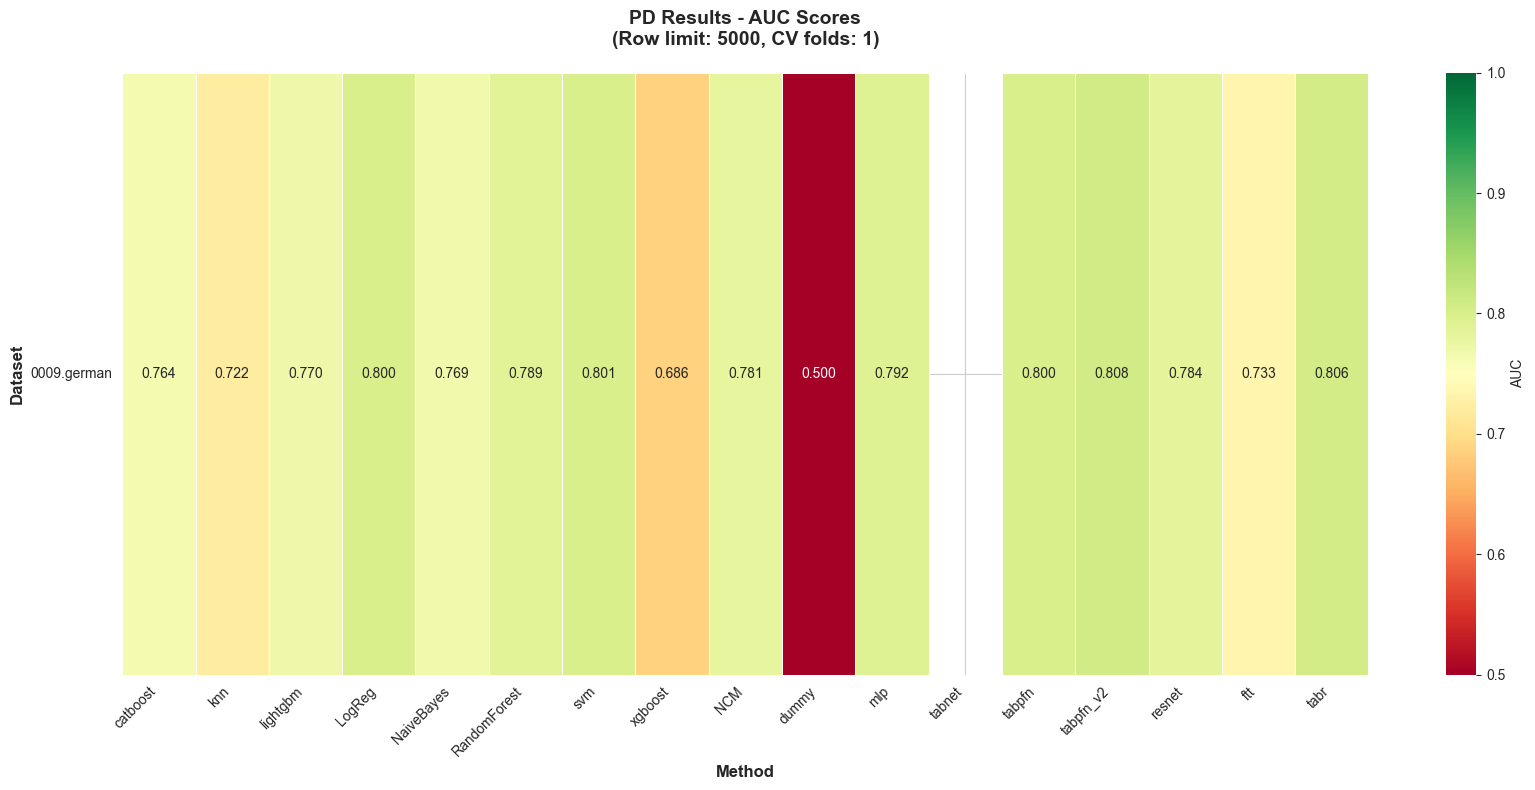

✓ LGD heatmap saved to: c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment_small\lgd_heatmap_20251217_120332.png


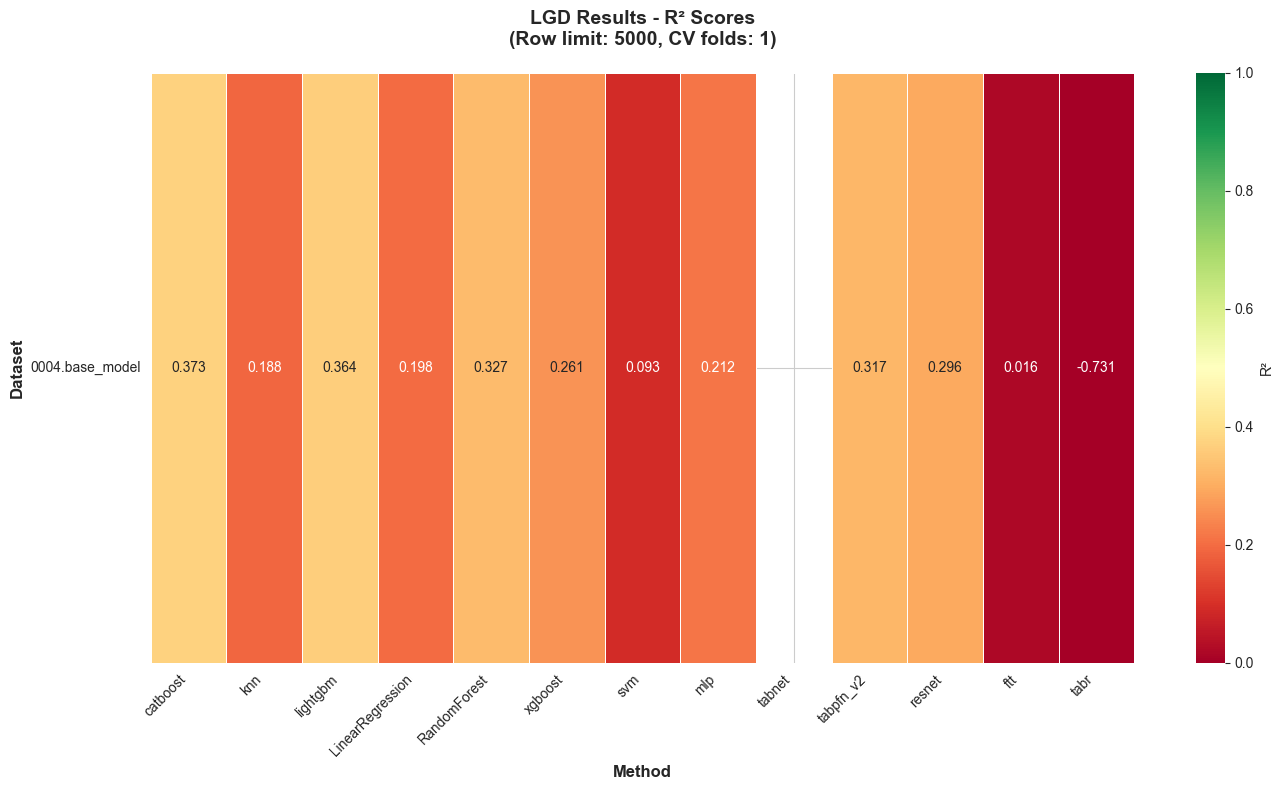


 EXPERIMENT COMPLETE
  Timestamp: 2025-12-17 12:03:34.152901
  Results saved in: c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment_small


In [2]:
# =============================================================================
# EXPERIMENT SMALL - Quick Benchmarking (CPU MODE)
# =============================================================================

# FORCE CPU MODE (add this FIRST)
import os
os.environ['CUDA_VISIBLE_DEVICES'] = ''

import sys
from pathlib import Path
import pickle
import json
import pandas as pd
import numpy as np
from datetime import datetime
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

# Verify CPU mode
import torch
print(f"\n{'='*80}")
print(f" COMPUTE MODE")
print(f"{'='*80}")
print(f"  CUDA Available: {torch.cuda.is_available()}")
print(f"  Device: CPU (forced)")
print(f"{'='*80}\n")

# -----------------------------------------------------------------------------
# CONFIGURATION
# -----------------------------------------------------------------------------

ROW_LIMIT = 5000
CV_SPLITS = 1
MAX_EPOCHS = 15
BATCH_SIZE = 1024
TUNE = False
SEED = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.2
EXCLUDE_METHODS = []

print(f"\n{'='*80}")
print(f" EXPERIMENT SMALL - Quick Benchmarking")
print(f"{'='*80}")
print(f"  Row limit:       {ROW_LIMIT}")
print(f"  CV splits:       {CV_SPLITS}")
print(f"  Max epochs:      {MAX_EPOCHS}")
print(f"  HPO:             {TUNE}")
print(f"  Device:          CPU")
print(f"  Excluded:        {', '.join(EXCLUDE_METHODS) if EXCLUDE_METHODS else 'None'}")
print(f"{'='*80}\n")

# -----------------------------------------------------------------------------
# LOAD CONFIGURATIONS
# -----------------------------------------------------------------------------

from src.utils.config_reader import load_config

config = load_config()

pd_datasets = list(config['datasets']['pd'].keys())
lgd_datasets = list(config['datasets']['lgd'].keys())

print(f"PD Datasets ({len(pd_datasets)}): {pd_datasets}")
print(f"LGD Datasets ({len(lgd_datasets)}): {lgd_datasets}")
print()

pd_methods_raw = list(config['methods']['pd'].keys())
lgd_methods_raw = list(config['methods']['lgd'].keys())

pd_methods = [m for m in pd_methods_raw if m not in EXCLUDE_METHODS]
lgd_methods = [m for m in lgd_methods_raw if m not in EXCLUDE_METHODS]

print(f"PD Methods ({len(pd_methods)}): {pd_methods}")
print(f"LGD Methods ({len(lgd_methods)}): {lgd_methods}")
print()

# -----------------------------------------------------------------------------
# RUN EXPERIMENTS
# -----------------------------------------------------------------------------

from src.methods.method_runner import run_talent_method

def run_single_experiment(task, dataset, method):
    """Run a single method-dataset combination and extract metric."""
    try:
        results = run_talent_method(
            task=task,
            dataset=dataset,
            test_size=TEST_SIZE,
            val_size=VAL_SIZE,
            cv_splits=CV_SPLITS,
            seed=SEED,
            row_limit=ROW_LIMIT,
            method=method,
            max_epoch=MAX_EPOCHS,
            batch_size=BATCH_SIZE,
            tune=TUNE,
            n_trials=20,
            early_stopping=True,
            early_stopping_patience=10,
            verbose=False,
        )
        
        if 1 in results:
            fold_results = results[1]
            metrics = fold_results['metrics']
            
            if task == 'pd':
                metric = metrics.get('AUC', np.nan)
            else:
                metric = metrics.get('R2', np.nan)
            
            return metric
        else:
            print(f"  WARNING: No fold 1 in results for {method} on {dataset}")
            return np.nan
            
    except Exception as e:
        print(f"  ERROR: {method} on {dataset} - {str(e)[:100]}")
        return np.nan


def run_task_experiments(task, datasets, methods):
    """Run all method-dataset combinations for a task."""
    metric_name = "AUC" if task == 'pd' else "R2"
    
    print(f"\n{'='*80}")
    print(f" Running {task.upper()} Experiments")
    print(f"{'='*80}")
    print(f"  Datasets: {len(datasets)}")
    print(f"  Methods:  {len(methods)}")
    print(f"  Total:    {len(datasets) * len(methods)} experiments")
    print(f"  Metric:   {metric_name}")
    print(f"{'='*80}\n")
    
    results_matrix = pd.DataFrame(index=datasets, columns=methods, dtype=float)
    total_experiments = len(datasets) * len(methods)
    
    with tqdm(total=total_experiments, desc=f"{task.upper()} Progress") as pbar:
        for dataset in datasets:
            for method in methods:
                pbar.set_description(f"{task.upper()}: {dataset[:20]:20s} + {method[:15]:15s}")
                metric = run_single_experiment(task, dataset, method)
                results_matrix.loc[dataset, method] = metric
                pbar.update(1)
    
    return results_matrix


# Run experiments
pd_results = run_task_experiments('pd', pd_datasets, pd_methods)
lgd_results = run_task_experiments('lgd', lgd_datasets, lgd_methods)

print("\n✓ All experiments completed!")

# -----------------------------------------------------------------------------
# DISPLAY RESULTS
# -----------------------------------------------------------------------------

print(f"\n{'='*80}")
print(f" PD RESULTS (AUC)")
print(f"{'='*80}\n")
print(pd_results.to_string())

print(f"\n{'='*80}")
print(f" LGD RESULTS (R²)")
print(f"{'='*80}\n")
print(lgd_results.to_string())

# -----------------------------------------------------------------------------
# SAVE RESULTS
# -----------------------------------------------------------------------------

output_dir = PROJECT_ROOT / 'results' / 'experiment_small'
output_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

pd_csv_path = output_dir / f"pd_results_auc_{timestamp}.csv"
pd_results.to_csv(pd_csv_path)
print(f"\n✓ PD results saved to: {pd_csv_path}")

lgd_csv_path = output_dir / f"lgd_results_r2_{timestamp}.csv"
lgd_results.to_csv(lgd_csv_path)
print(f"✓ LGD results saved to: {lgd_csv_path}")

config_summary = {
    'timestamp': timestamp,
    'settings': {
        'row_limit': ROW_LIMIT,
        'cv_splits': CV_SPLITS,
        'max_epochs': MAX_EPOCHS,
        'batch_size': BATCH_SIZE,
        'tune': TUNE,
        'seed': SEED,
        'test_size': TEST_SIZE,
        'val_size': VAL_SIZE,
        'excluded_methods': EXCLUDE_METHODS,
    },
    'compute': {
        'device': 'CPU',
        'cuda_available': False,
    },
    'datasets': {
        'pd': pd_datasets,
        'lgd': lgd_datasets,
    },
    'methods': {
        'pd': pd_methods,
        'lgd': lgd_methods,
    },
    'metrics': {
        'pd': 'AUC',
        'lgd': 'R²'
    },
    'n_experiments': len(pd_datasets) * len(pd_methods) + len(lgd_datasets) * len(lgd_methods),
}

config_path = output_dir / f"config_{timestamp}.json"
with open(config_path, 'w') as f:
    json.dump(config_summary, f, indent=2)
print(f"✓ Configuration saved to: {config_path}")

# -----------------------------------------------------------------------------
# SUMMARY STATISTICS
# -----------------------------------------------------------------------------

print(f"\n{'='*80}")
print(f" SUMMARY STATISTICS")
print(f"{'='*80}")

if len(pd_results) > 0 and not pd_results.empty:
    print(f"\n[PD TASK - AUC]")
    print(f"  Best method overall:     {pd_results.mean(axis=0).idxmax()} (Avg: {pd_results.mean(axis=0).max():.4f})")
    print(f"  Worst method overall:    {pd_results.mean(axis=0).idxmin()} (Avg: {pd_results.mean(axis=0).min():.4f})")
    print(f"  Hardest dataset:         {pd_results.mean(axis=1).idxmin()} (Avg: {pd_results.mean(axis=1).min():.4f})")
    print(f"  Easiest dataset:         {pd_results.mean(axis=1).idxmax()} (Avg: {pd_results.mean(axis=1).max():.4f})")
    print(f"  Experiments completed:   {pd_results.notna().sum().sum()} / {pd_results.size}")
    print(f"  Failed experiments:      {pd_results.isna().sum().sum()}")

if len(lgd_results) > 0 and not lgd_results.empty:
    print(f"\n[LGD TASK - R²]")
    print(f"  Best method overall:     {lgd_results.mean(axis=0).idxmax()} (Avg: {lgd_results.mean(axis=0).max():.4f})")
    print(f"  Worst method overall:    {lgd_results.mean(axis=0).idxmin()} (Avg: {lgd_results.mean(axis=0).min():.4f})")
    print(f"  Hardest dataset:         {lgd_results.mean(axis=1).idxmin()} (Avg: {lgd_results.mean(axis=1).min():.4f})")
    print(f"  Easiest dataset:         {lgd_results.mean(axis=1).idxmax()} (Avg: {lgd_results.mean(axis=1).max():.4f})")
    print(f"  Experiments completed:   {lgd_results.notna().sum().sum()} / {lgd_results.size}")
    print(f"  Failed experiments:      {lgd_results.isna().sum().sum()}")

# -----------------------------------------------------------------------------
# VISUALIZATIONS
# -----------------------------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

if len(pd_results) > 0 and not pd_results.empty:
    fig, ax = plt.subplots(figsize=(max(14, len(pd_methods) * 1.0), 
                                     max(8, len(pd_datasets) * 0.5)))
    
    sns.heatmap(
        pd_results.astype(float), 
        annot=True, 
        fmt='.3f', 
        cmap='RdYlGn',
        center=0.75, 
        vmin=0.5, 
        vmax=1.0,
        cbar_kws={'label': 'AUC'},
        linewidths=0.5,
        ax=ax
    )
    
    ax.set_title(
        f'PD Results - AUC Scores\n(Row limit: {ROW_LIMIT}, CV folds: {CV_SPLITS})',
        fontsize=14,
        fontweight='bold',
        pad=20
    )
    ax.set_xlabel('Method', fontsize=12, fontweight='bold')
    ax.set_ylabel('Dataset', fontsize=12, fontweight='bold')
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    heatmap_path = output_dir / f"pd_heatmap_{timestamp}.png"
    plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ PD heatmap saved to: {heatmap_path}")
    plt.show()

if len(lgd_results) > 0 and not lgd_results.empty:
    fig, ax = plt.subplots(figsize=(max(14, len(lgd_methods) * 1.0),
                                     max(8, len(lgd_datasets) * 0.5)))
    
    sns.heatmap(
        lgd_results.astype(float),
        annot=True,
        fmt='.3f',
        cmap='RdYlGn',
        center=0.5,
        vmin=0.0,
        vmax=1.0,
        cbar_kws={'label': 'R²'},
        linewidths=0.5,
        ax=ax
    )
    
    ax.set_title(
        f'LGD Results - R² Scores\n(Row limit: {ROW_LIMIT}, CV folds: {CV_SPLITS})',
        fontsize=14,
        fontweight='bold',
        pad=20
    )
    ax.set_xlabel('Method', fontsize=12, fontweight='bold')
    ax.set_ylabel('Dataset', fontsize=12, fontweight='bold')
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    heatmap_path = output_dir / f"lgd_heatmap_{timestamp}.png"
    plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
    print(f"✓ LGD heatmap saved to: {heatmap_path}")
    plt.show()

print(f"\n{'='*80}")
print(f" EXPERIMENT COMPLETE")
print(f"{'='*80}")
print(f"  Timestamp: {datetime.now()}")
print(f"  Results saved in: {output_dir}")
print(f"{'='*80}")